In [13]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd 

PATHIM = "data//cnd_large//images.csv" 
PATHLB = "data//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


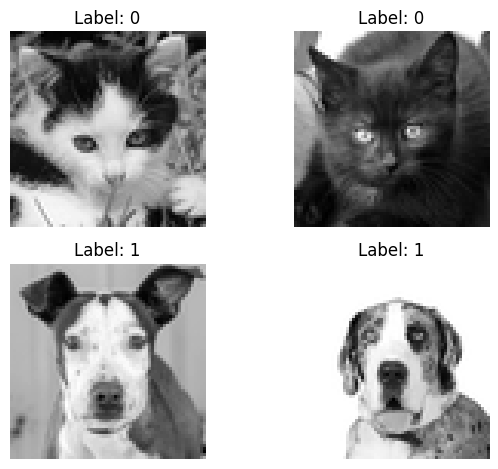

In [14]:
import matplotlib.pyplot as plt
import numpy as np




images = np.array(images)
labels = np.array(labels).ravel() #Ravel redundant here?


#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])

images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [15]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = images
y = labels

# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_train_full = X_train_full.shape[0]
fractions = np.linspace(1.0, 0.1, 10)
print(fractions)

results = { "svd": [], "shrink": [] }
rng = np.random.RandomState(0)

for f in fractions:
    n_keep = int(n_train_full * f)
    idx = rng.choice(n_train_full, n_keep, replace=False)
    X_train = X_train_full[idx]
    y_train = y_train_full[idx]

    # SVD solver (fastest)
    try:
        acc_svd = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train).predict(X_test)
        )
    except:
        acc_svd = np.nan

    # Regularized / shrunk LDA (fast, avoids singularity)
    try:
        acc_shrink = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
            .fit(X_train, y_train)
            .predict(X_test)
        )
    except:
        acc_shrink = np.nan

    results["svd"].append((f, acc_svd))
    results["shrink"].append((f, acc_shrink))

# Print
for name in results:
    print(f"\n== {name} ==")
    for f, acc in results[name]:
        print(f"Fraction {f:.2f}: acc = {acc:.3f}")

[1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]

== svd ==
Fraction 1.00: acc = 0.689
Fraction 0.90: acc = 0.670
Fraction 0.80: acc = 0.648
Fraction 0.70: acc = 0.606
Fraction 0.60: acc = 0.545
Fraction 0.50: acc = 0.599
Fraction 0.40: acc = 0.660
Fraction 0.30: acc = 0.674
Fraction 0.20: acc = 0.723
Fraction 0.10: acc = 0.738

== shrink ==
Fraction 1.00: acc = 0.756
Fraction 0.90: acc = 0.746
Fraction 0.80: acc = 0.745
Fraction 0.70: acc = 0.747
Fraction 0.60: acc = 0.733
Fraction 0.50: acc = 0.728
Fraction 0.40: acc = 0.729
Fraction 0.30: acc = 0.710
Fraction 0.20: acc = 0.726
Fraction 0.10: acc = 0.730


## GENERATE INITIAL Train / Test Set

In [30]:
SEED = 127

X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

## Set up CV Pipelines

In [ ]:
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SEED = 42

X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=SEED)

lda_param_grid = {
    'filter__k': [100,200,300,400, 500],
    'lasso__estimator__C': [0.001, .01,.1,1,10]
}

log_reg_param_grid = {

}

svm_param_grid = {
    'filter__k': [100,200,300,400, 500],
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 1, 10]
}

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("filter", SelectKBest(score_func=f_classif)),
    ("svm", SVC(random_state=SEED))
])

## Update pipeline for LogReg (include scaler and add SelectFromModel / second LogReg)
## Want to compare running unconstrained logreg after using initial logreg for parameter selection
log_reg_pipeline_2 = Pipeline([
    ("scaler", StandardScaler()),
    ('filter', SelectKBest(score_func=f_classif)),
    ('lasso', SelectFromModel(
        LogisticRegression(l1_ratio=1.0, solver='saga', max_iter=3000, random_state=SEED)
    )),
    #No lambda (1/lambda = c = C = 1e8) #So no very low constraint 
    ('regression', LogisticRegression(solver='saga', max_iter=3000, random_state=SEED, C=1e8))
])


lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ('filter', SelectKBest(f_classif)),
    ('lasso', SelectFromModel(LogisticRegression(
        l1_ratio=1.0,
        solver='saga',
        max_iter = 5000,
        random_state=SEED #Needed in case
    ))),
    ('lda', LinearDiscriminantAnalysis(solver='svd'))
])


In [ ]:
grid = GridSearchCV(
    lda_pipe,
    lda_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs = -1
)

grid.fit(X_TRAIN, Y_TRAIN)
grid.best_estimator_.named_steps['filter'].get_support()
grid.best_estimator_.named_steps['lasso'].get_support()
results = pd.DataFrame(grid.cv_results_)


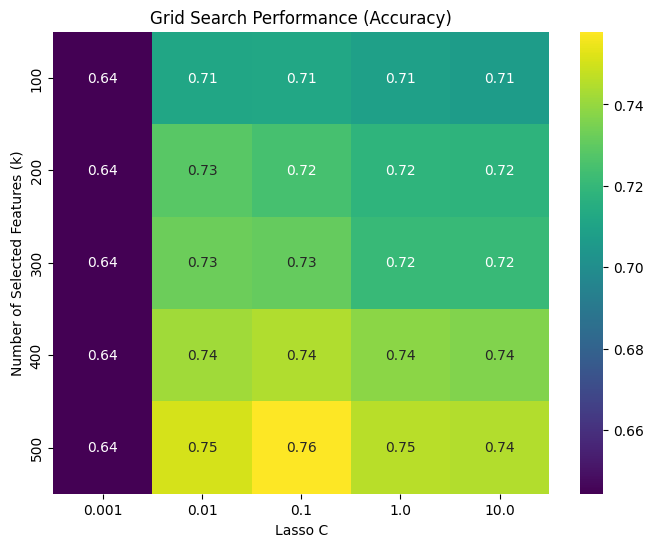

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot_table(
    values='mean_test_score',
    index='param_filter__k',
    columns='param_lasso__estimator__C'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Grid Search Performance (Accuracy)")
plt.xlabel("Lasso C")
plt.ylabel("Number of Selected Features (k)")
plt.show()

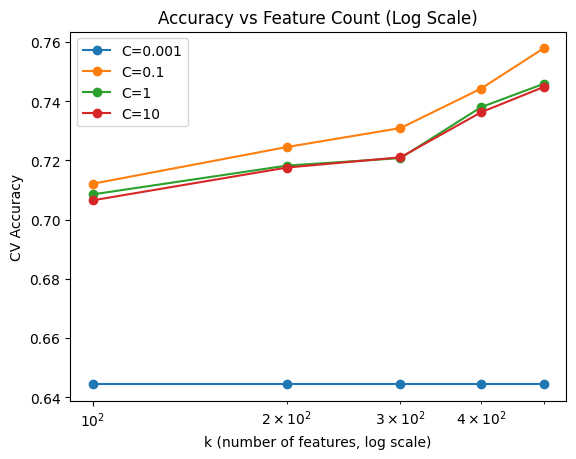

In [34]:
import matplotlib.pyplot as plt

for C in [0.001, 0.1, 1, 10]:
    subset = results[results['param_lasso__estimator__C'] == C]

    plt.plot(
        subset['param_filter__k'],
        subset['mean_test_score'],
        marker='o',
        label=f"C={C}"
    )

plt.xscale('log')

plt.xlabel("k (number of features, log scale)")
plt.ylabel("CV Accuracy")
plt.title("Accuracy vs Feature Count (Log Scale)")
plt.legend()
plt.show()

### Before Lasso

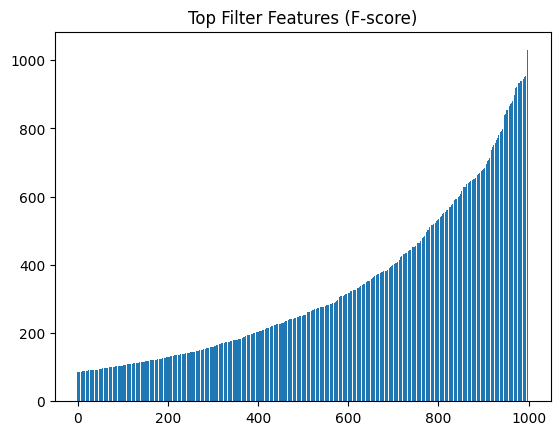

In [35]:
import numpy as np

scores = grid.best_estimator_.named_steps['filter'].scores_

top_k = 1_000
idx = np.argsort(scores)[-top_k:]

plt.figure()
plt.bar(range(top_k), scores[idx])
plt.title("Top Filter Features (F-score)")
plt.show()

### After Lasso

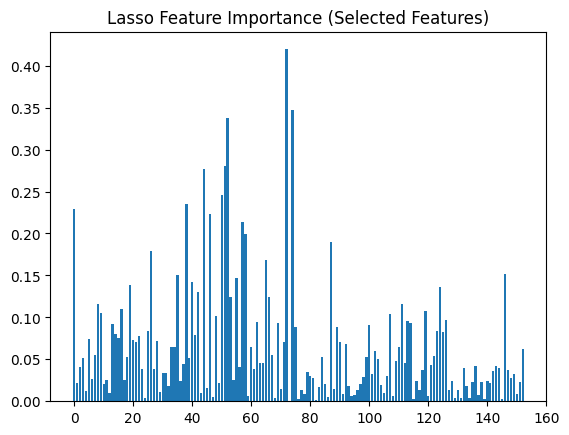

In [36]:
lasso_model = grid.best_estimator_.named_steps['lasso'].estimator_
coef = np.abs(lasso_model.coef_).ravel()

support = grid.best_estimator_.named_steps['lasso'].get_support()

selected_coef = coef[support]

plt.figure()
plt.bar(range(len(selected_coef)), selected_coef)
plt.title("Lasso Feature Importance (Selected Features)")
plt.show()

In [37]:
filter_scores = grid.best_estimator_.named_steps['filter'].scores_

In [38]:
lasso = grid.best_estimator_.named_steps['lasso'].estimator_
coef = np.abs(lasso.coef_).ravel()

mask = grid.best_estimator_.named_steps['filter'].get_support()

full_lasso = np.zeros_like(filter_scores)
full_lasso[mask] = coef

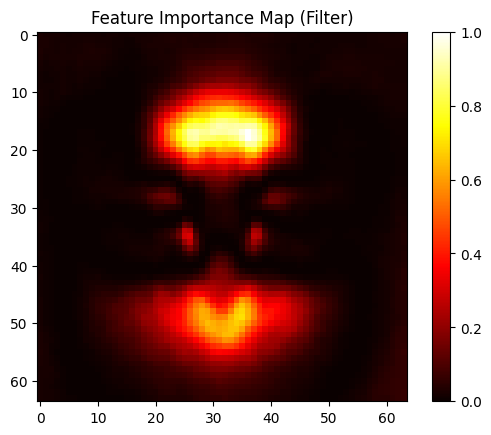

In [39]:
import matplotlib.pyplot as plt

importance = filter_scores  # or filter_scores

importance = importance - importance.min()
importance = importance / importance.max()

img_shape = (64, 64)
importance_img = importance.reshape(img_shape)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Map (Filter)")
plt.colorbar()
plt.show()

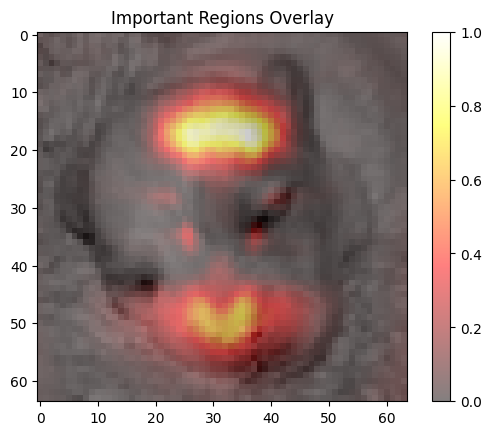

In [40]:
import random

sample_image = X_TRAIN[random.randint(0,len(X_TRAIN))]
sample_image = sample_image.reshape(64,64)

plt.imshow(sample_image, cmap='gray')
plt.imshow(importance_img, cmap='hot', alpha=0.5)
plt.title("Important Regions Overlay")
plt.colorbar()
plt.show()

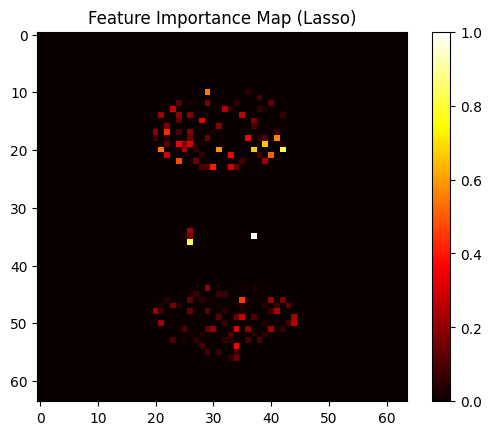

In [41]:
import matplotlib.pyplot as plt

importance = full_lasso

importance = importance - importance.min()
importance = importance / importance.max()

img_shape = (64, 64)
importance_img = importance.reshape(img_shape)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Map (Lasso)")
plt.colorbar()
plt.show()

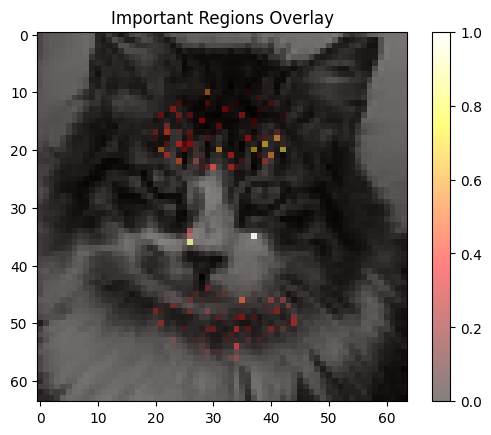

In [42]:
import random

sample_image = X_TRAIN[random.randint(0,len(X_TRAIN))]
sample_image = sample_image.reshape(64,64)

plt.imshow(sample_image, cmap='gray')
plt.imshow(importance_img, cmap='hot', alpha=0.5)
plt.title("Important Regions Overlay")
plt.colorbar()
plt.show()

# Flipping images

In [77]:
X_TRAIN_FLIPPED = X_TRAIN.copy()
X_TEST_FLIPPED = X_TEST.copy()

num_train = len(X_TRAIN_FLIPPED)


train_flip_indices = np.random.choice(
    num_train,
    size= num_train // 2,
    replace=False
)


X_TRAIN_FLIPPED[train_flip_indices] = np.flip(X_TRAIN_FLIPPED[train_flip_indices],axis=1)




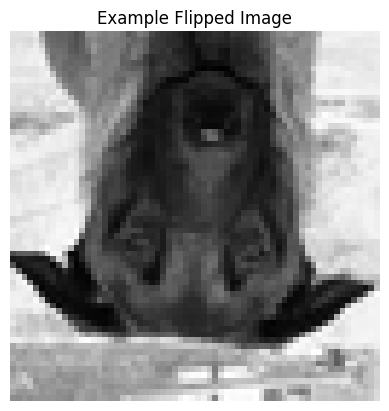

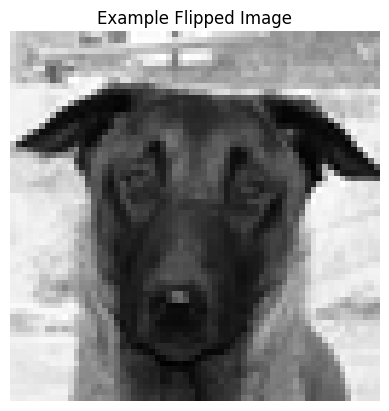

In [78]:
import matplotlib.pyplot as plt

# Pick one flipped image to display
idx = train_flip_indices[0]

plt.imshow(X_TRAIN_FLIPPED[idx].reshape(64,64), cmap='gray')
plt.title("Example Flipped Image")
plt.axis("off")
plt.show()

plt.imshow(X_TRAIN[idx].reshape(64,64), cmap='gray')
plt.title("Example Flipped Image")
plt.axis("off")
plt.show()

In [79]:
grid = GridSearchCV(
    lda_pipe,
    lda_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs = -1
)

grid.fit(X_TRAIN_FLIPPED, Y_TRAIN)
grid.best_estimator_.named_steps['filter'].get_support()
grid.best_estimator_.named_steps['lasso'].get_support()
results = pd.DataFrame(grid.cv_results_)

C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
25 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\BetterOffBread\AppData\Local\Pac

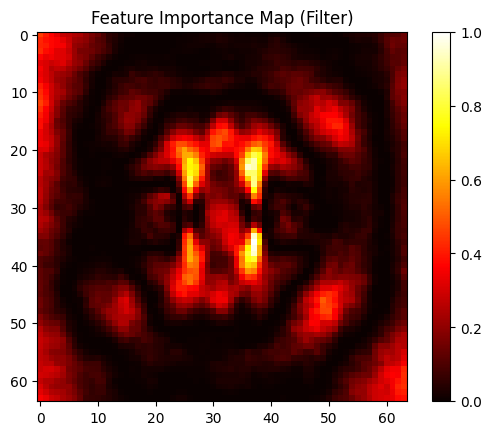

In [80]:
filter_scores = grid.best_estimator_.named_steps['filter'].scores_

importance = filter_scores  # or filter_scores

importance = importance - importance.min()
importance = importance / importance.max()

img_shape = (64, 64)
importance_img = importance.reshape(img_shape)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Map (Filter)")
plt.colorbar()
plt.show()

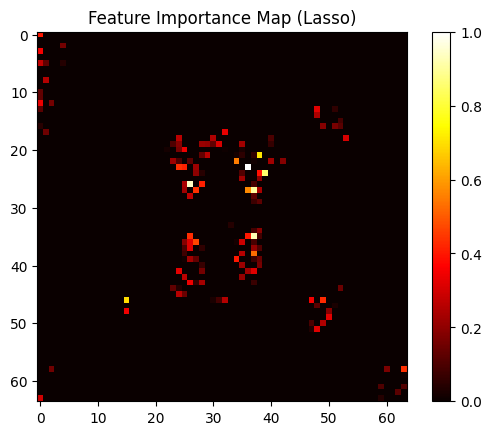

In [81]:
lasso = grid.best_estimator_.named_steps['lasso'].estimator_
coef = np.abs(lasso.coef_).ravel()

mask = grid.best_estimator_.named_steps['filter'].get_support()

full_lasso = np.zeros_like(filter_scores)
full_lasso[mask] = coef

importance = full_lasso

importance = importance - importance.min()
importance = importance / importance.max()

img_shape = (64, 64)
importance_img = importance.reshape(img_shape)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Map (Lasso)")
plt.colorbar()
plt.show()

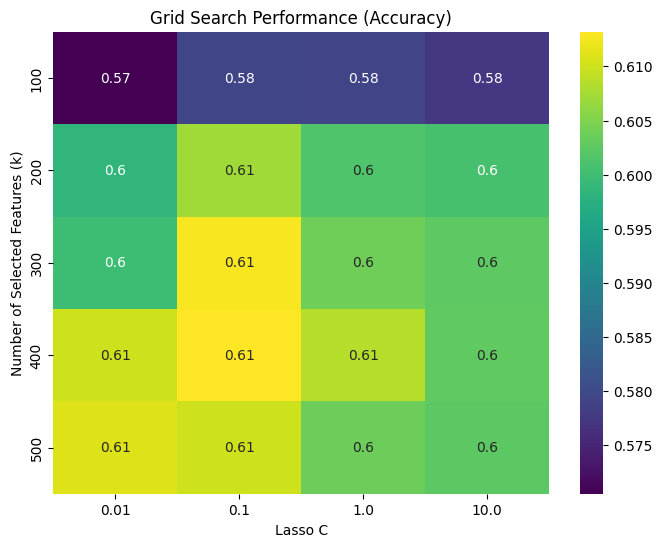

In [82]:
results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot_table(
    values='mean_test_score',
    index='param_filter__k',
    columns='param_lasso__estimator__C'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Grid Search Performance (Accuracy)")
plt.xlabel("Lasso C")
plt.ylabel("Number of Selected Features (k)")
plt.show()